# Analyse Exploratoire des Données (EDA)
## Projet Churn Prediction — EFREI M1 Data Engineering

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/customer_churn.csv')
print(df.shape)
df.head()

(10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_method,payment_failures,discount_applied,price_increase_last_3m,support_tickets,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,7,11.762372,5,0.06,7,30,660,PayPal,1,Yes,No,4,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,5,26.846390,1,-0.28,2,30,270,Card,1,No,Yes,1,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,5,23.380065,6,0.13,23,20,1160,Card,2,No,No,1,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,7,24.243136,2,-0.17,24,30,570,Bank Transfer,0,Yes,No,3,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,6,18.872323,2,-0.16,2,50,2600,PayPal,0,No,No,0,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


## 1. Aperçu général

In [2]:
print('Types de données :')
print(df.dtypes)
print('\nValeurs manquantes :')
print(df.isnull().sum())
print('\nStatistiques descriptives :')
df.describe()

Types de données :
customer_id                   str
gender                        str
age                         int64
country                       str
city                          str
customer_segment              str
tenure_months               int64
signup_channel                str
contract_type                 str
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method                str
payment_failures            int64
discount_applied              str
price_increase_last_3m        str
support_tickets             int64
avg_resolution_time       float64
complaint_type                str
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score                   i

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


## 2. Distribution de la variable cible (churn)

Churn rate : 10.2%
churn
0    8979
1    1021
Name: count, dtype: int64


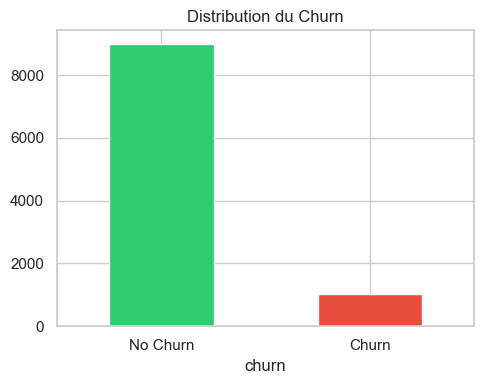

In [3]:
churn_counts = df['churn'].value_counts()
print(f'Churn rate : {df["churn"].mean():.1%}')
print(churn_counts)

fig, ax = plt.subplots(figsize=(5, 4))
churn_counts.plot.bar(ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['No Churn', 'Churn'], rotation=0)
ax.set_title('Distribution du Churn')
plt.tight_layout()
plt.show()

## 3. Distributions des variables numériques

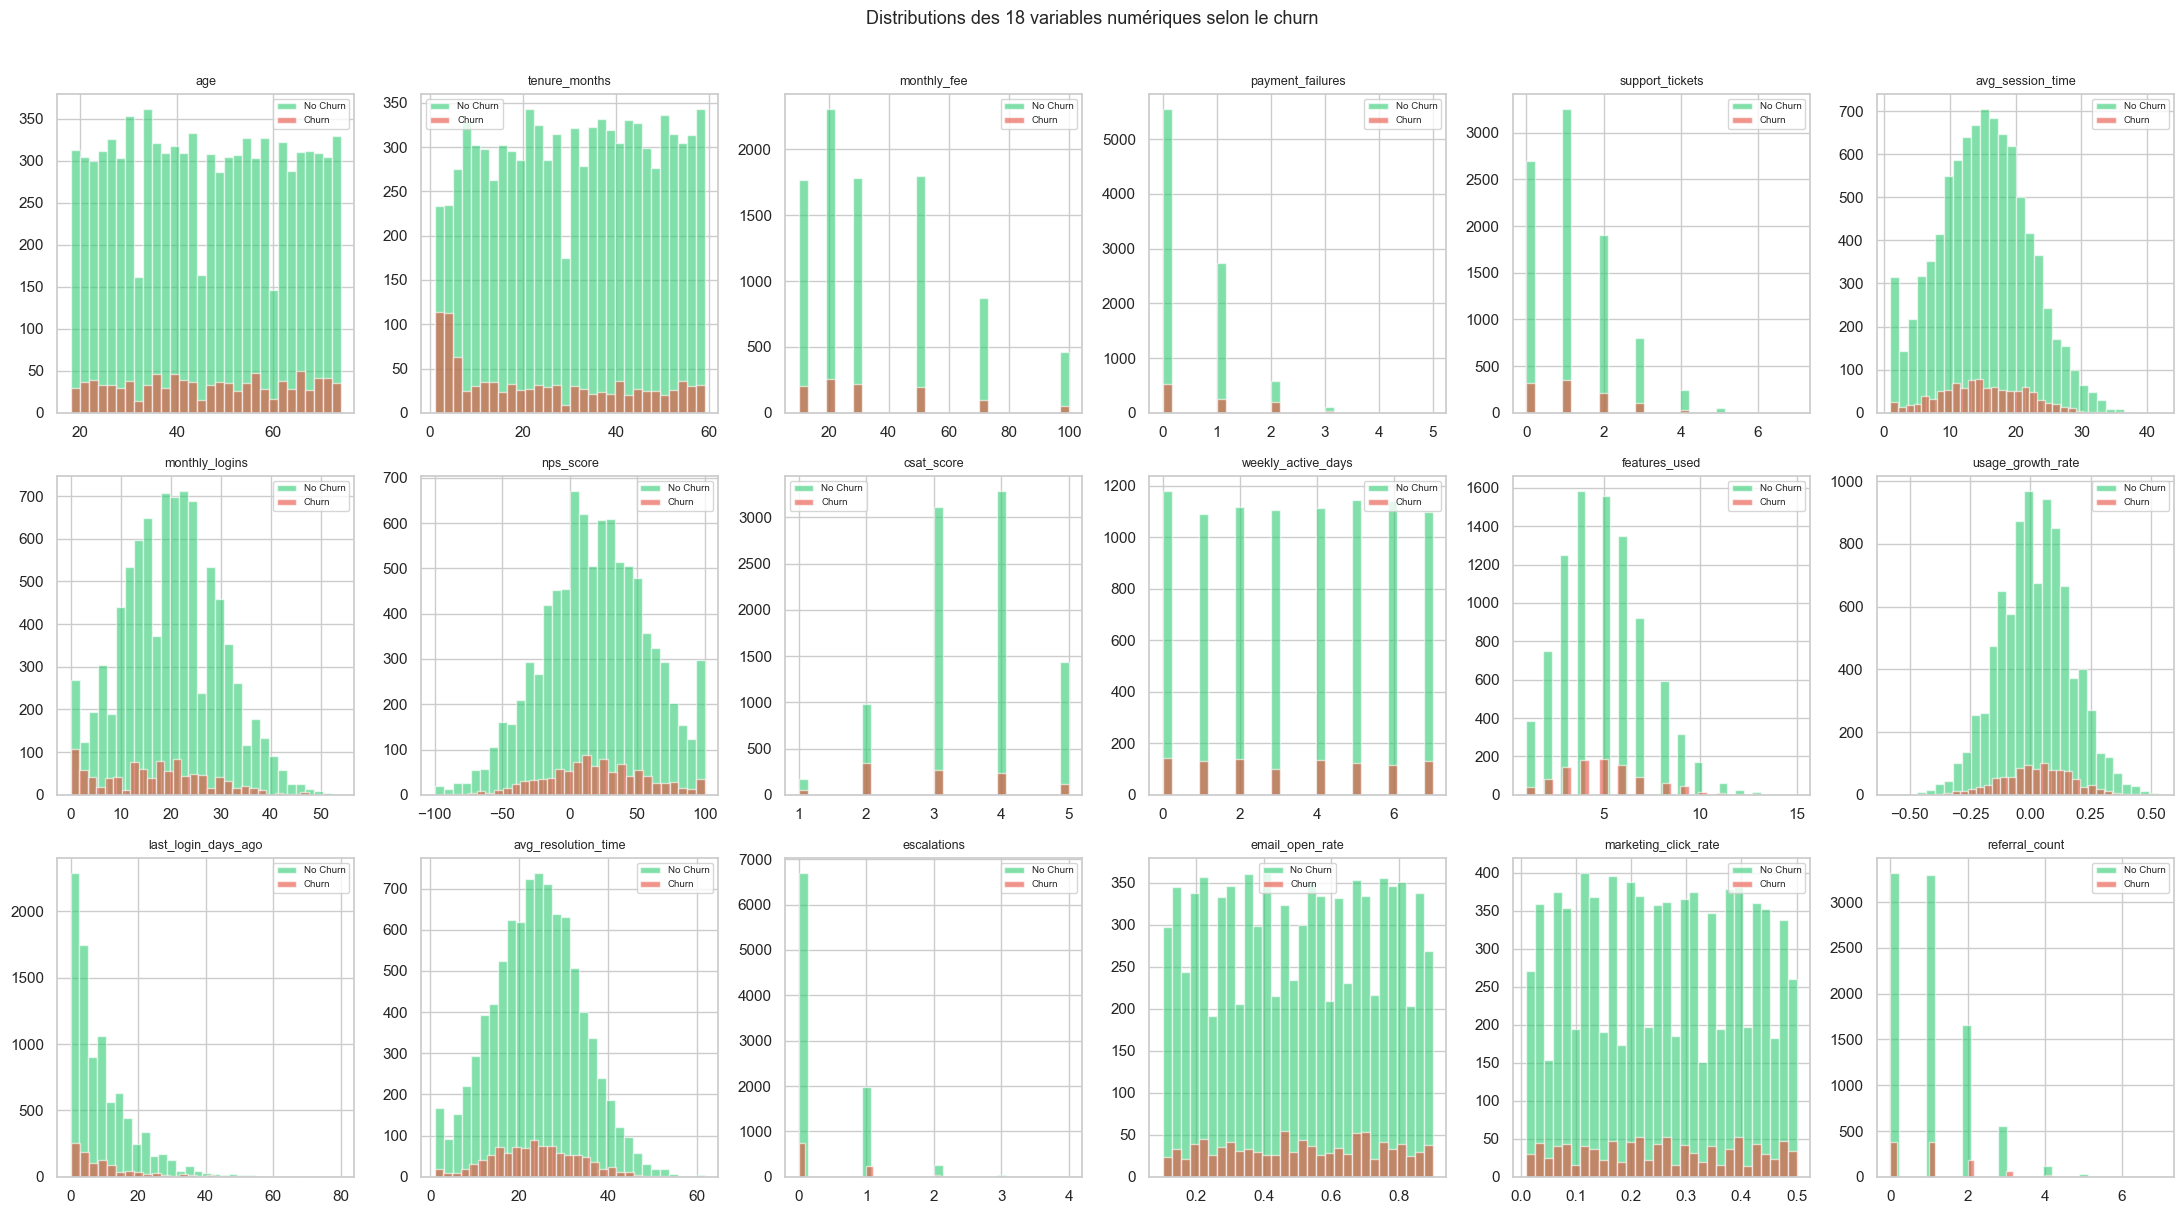

In [4]:
from src.preprocessing import NUMERIC_FEATURES
numeric_cols = NUMERIC_FEATURES  # 18 features, sans total_revenue

fig, axes = plt.subplots(3, 6, figsize=(22, 12))
for ax, col in zip(axes.flatten(), numeric_cols):
    df[df['churn'] == 0][col].hist(ax=ax, alpha=0.6, color='#2ecc71', label='No Churn', bins=30)
    df[df['churn'] == 1][col].hist(ax=ax, alpha=0.6, color='#e74c3c', label='Churn', bins=30)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
# Cacher les axes vides
for ax in axes.flatten()[len(numeric_cols):]:
    ax.set_visible(False)
plt.suptitle('Distributions des 18 variables numériques selon le churn', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 3b. Boxplots — Séparation Churn / Fidèles par variable clé

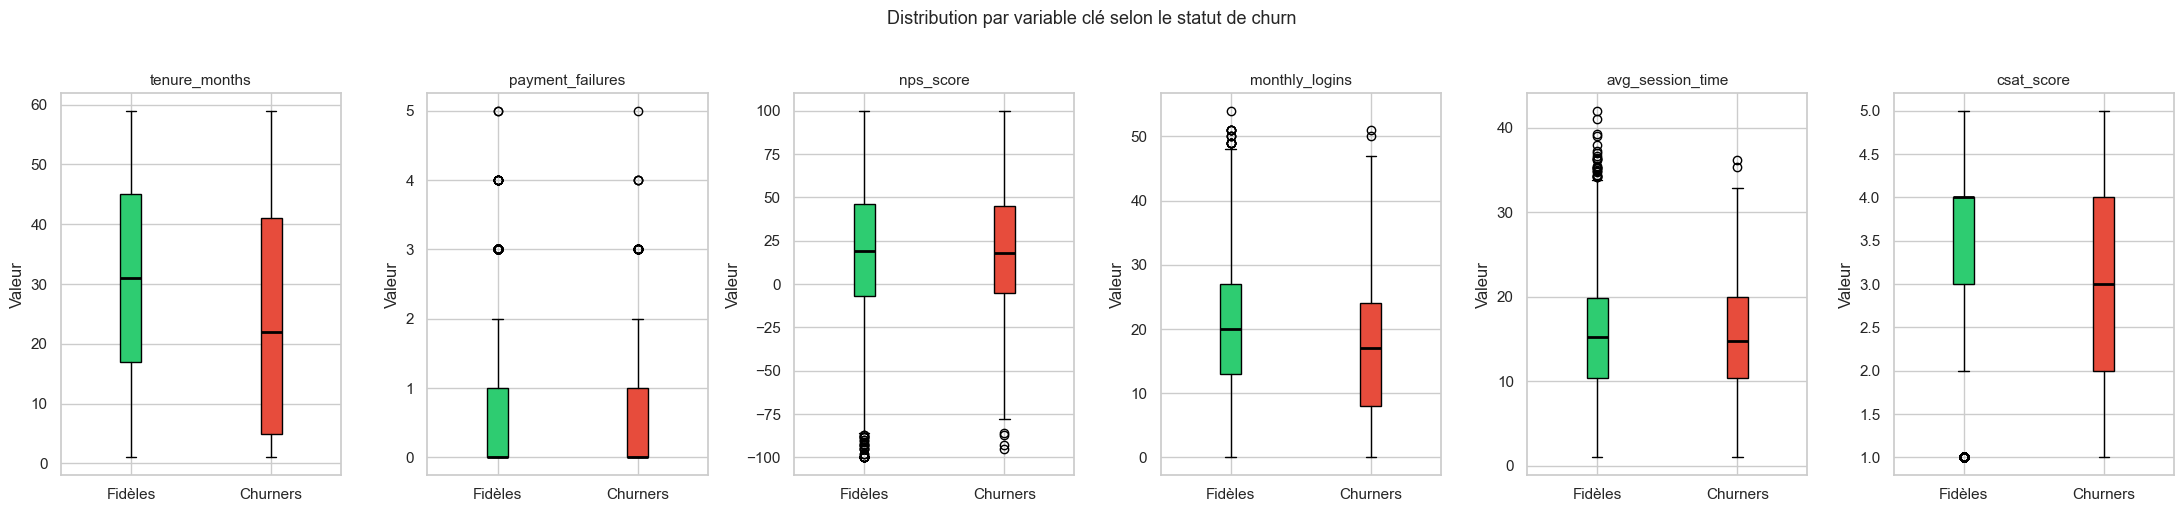

Médiane tenure_months — Fidèles : 31.0
Médiane tenure_months — Churners: 22.0
Médiane csat_score — Fidèles : 4.0
Médiane csat_score — Churners: 3.0
Médiane payment_failures — Fidèles : 0.0
Médiane payment_failures — Churners: 0.0


In [5]:
# Boxplots des variables les plus discriminantes selon le churn
key_vars = ['tenure_months', 'payment_failures', 'nps_score',
            'monthly_logins', 'avg_session_time', 'csat_score']

fig, axes = plt.subplots(1, 6, figsize=(22, 5))
for ax, col in zip(axes, key_vars):
    groups = [df[df['churn'] == 0][col], df[df['churn'] == 1][col]]
    bp = ax.boxplot(groups, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_xticklabels(['Fidèles', 'Churners'])
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Valeur')

fig.suptitle('Distribution par variable clé selon le statut de churn', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Médiane tenure_months — Fidèles :', df[df.churn==0]['tenure_months'].median())
print('Médiane tenure_months — Churners:', df[df.churn==1]['tenure_months'].median())
print('Médiane csat_score — Fidèles :', df[df.churn==0]['csat_score'].median())
print('Médiane csat_score — Churners:', df[df.churn==1]['csat_score'].median())
print('Médiane payment_failures — Fidèles :', df[df.churn==0]['payment_failures'].median())
print('Médiane payment_failures — Churners:', df[df.churn==1]['payment_failures'].median())


## 4. Matrice de corrélation

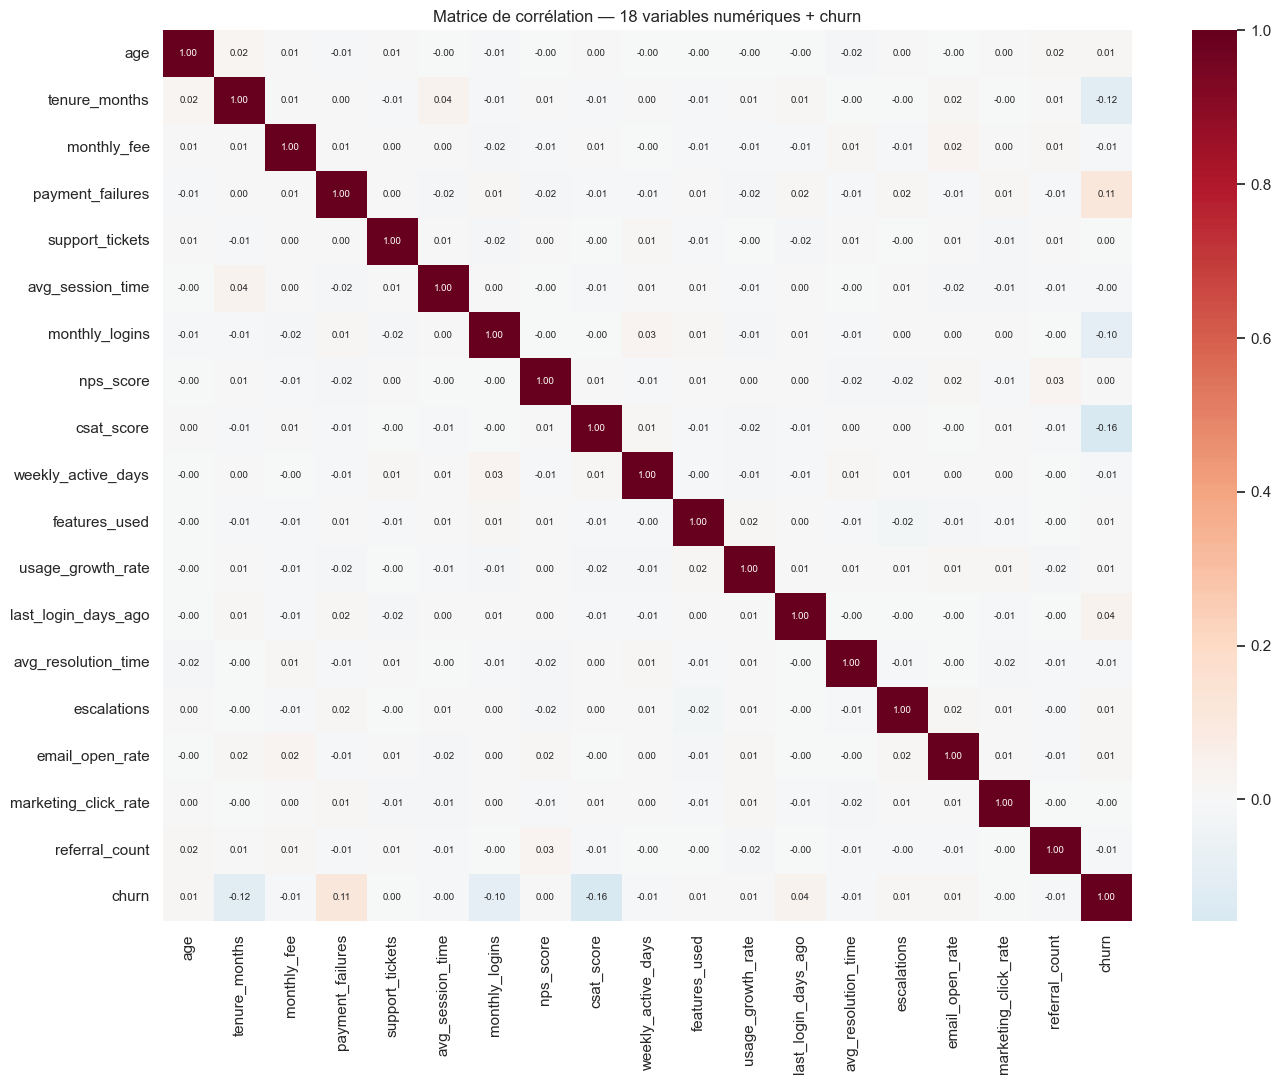


Corrélation avec churn :
churn                   1.000000
payment_failures        0.112494
last_login_days_ago     0.037250
email_open_rate         0.011506
age                     0.010155
escalations             0.009561
features_used           0.005435
usage_growth_rate       0.005276
nps_score               0.002996
support_tickets         0.000317
marketing_click_rate   -0.002068
avg_session_time       -0.004659
monthly_fee            -0.005048
referral_count         -0.007323
weekly_active_days     -0.008818
avg_resolution_time    -0.009172
monthly_logins         -0.098339
tenure_months          -0.117014
csat_score             -0.157924
Name: churn, dtype: float64


In [6]:
corr = df[numeric_cols + ['churn']].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, annot_kws={'size': 7})
plt.title('Matrice de corrélation — 18 variables numériques + churn', fontsize=12)
plt.tight_layout()
plt.show()

print('\nCorrélation avec churn :')
print(corr['churn'].sort_values(ascending=False))


## 5. Variables catégorielles vs Churn

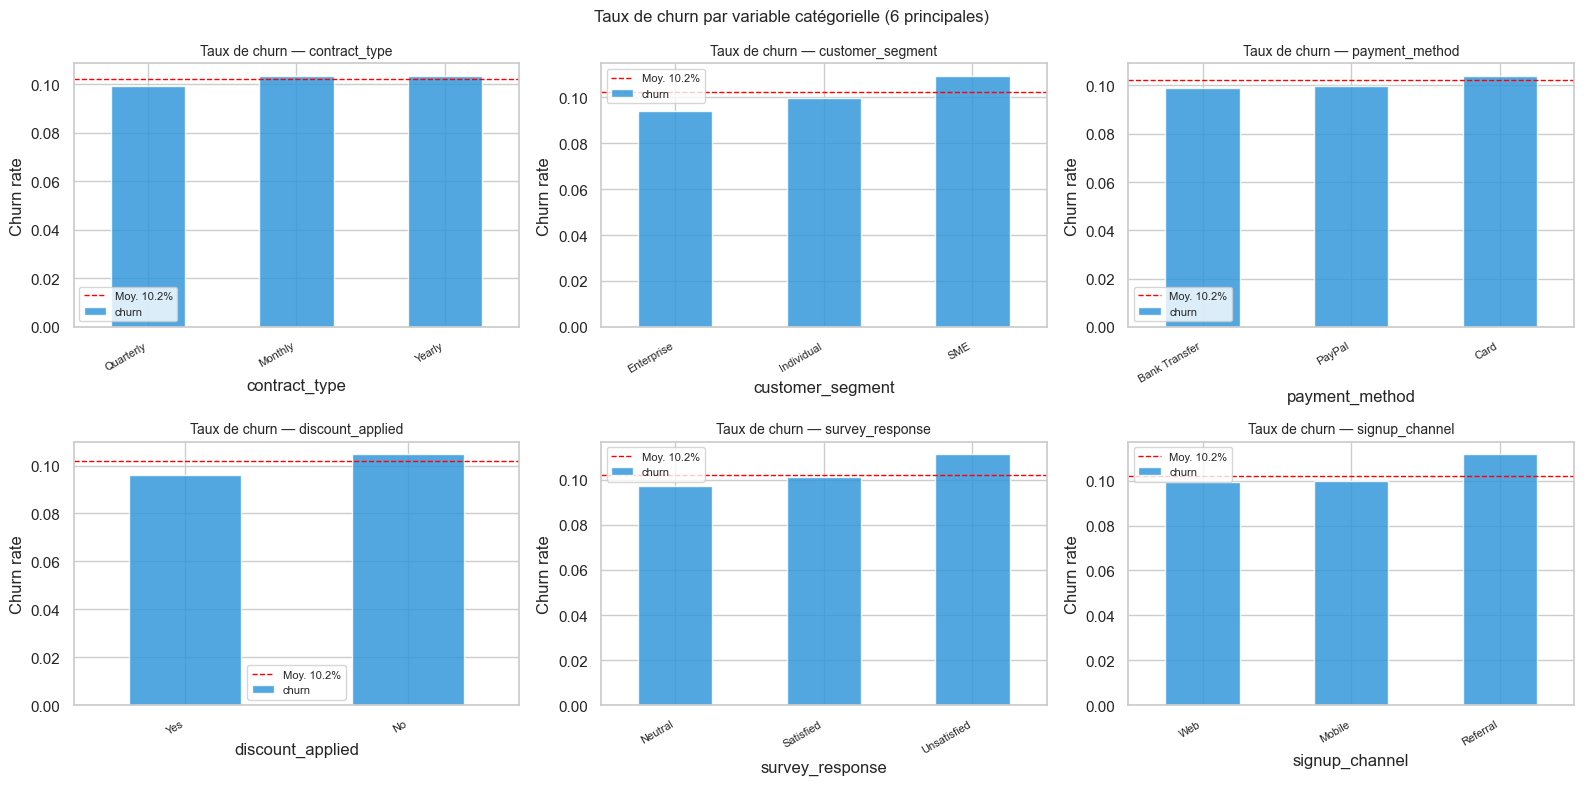

In [7]:
cat_cols = ['contract_type', 'customer_segment', 'payment_method',
            'discount_applied', 'survey_response', 'signup_channel']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    churn_rate = df.groupby(col)['churn'].mean().sort_values()
    bars = churn_rate.plot.bar(ax=ax, color='#3498db', alpha=0.85)
    ax.axhline(df['churn'].mean(), color='red', linestyle='--', linewidth=1, label=f'Moy. {df["churn"].mean():.1%}')
    ax.set_title(f'Taux de churn — {col}', fontsize=10)
    ax.set_ylabel('Churn rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.legend(fontsize=8)
plt.suptitle('Taux de churn par variable catégorielle (6 principales)', fontsize=12)
plt.tight_layout()
plt.show()


## 6. Analyse du revenu à risque

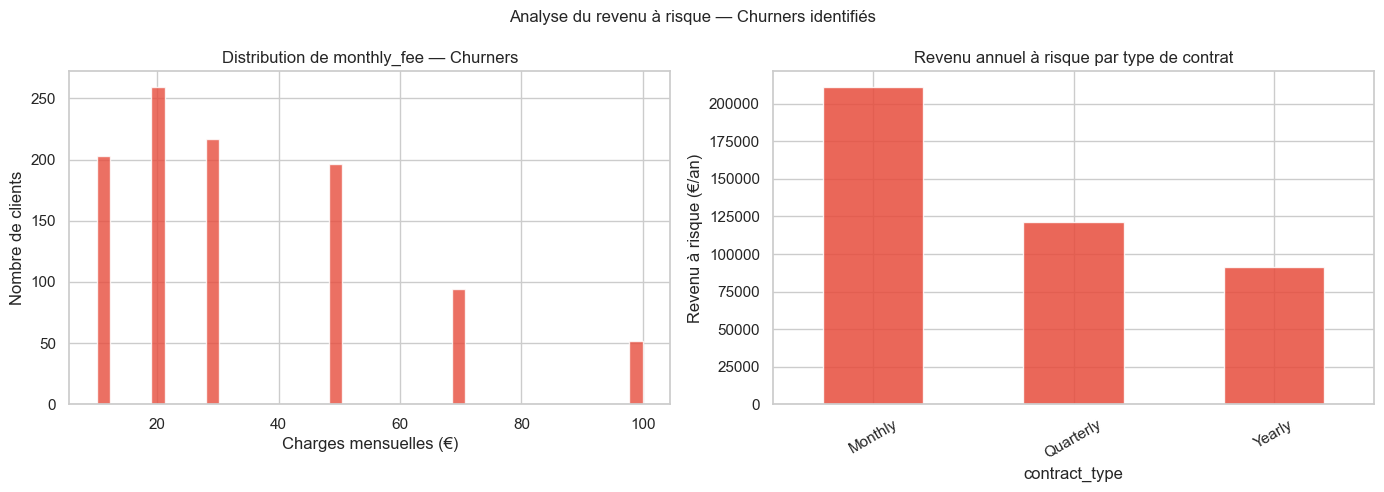

Revenu total à risque (annual) : 423,600 €
Clients à risque : 1021
Revenu moyen par churner : 415 €/an


In [8]:
# total_revenue est exclu (= monthly_fee x tenure_months, redondance exacte)
# On visualise à la place la distribution du revenu à risque par contrat
churners = df[df['churn'] == 1].copy()
churners['revenue_at_risk'] = churners['monthly_fee'] * 12

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des charges mensuelles pour les churners
axes[0].hist(churners['monthly_fee'], bins=40, color='#e74c3c', alpha=0.8)
axes[0].set_title('Distribution de monthly_fee — Churners')
axes[0].set_xlabel('Charges mensuelles (€)')
axes[0].set_ylabel('Nombre de clients')

# Revenu à risque annuel par type de contrat
rev_by_contract = df[df['churn']==1].groupby('contract_type')['monthly_fee'].sum() * 12
rev_by_contract.plot.bar(ax=axes[1], color='#e74c3c', alpha=0.85)
axes[1].set_title('Revenu annuel à risque par type de contrat')
axes[1].set_ylabel('Revenu à risque (€/an)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.suptitle('Analyse du revenu à risque — Churners identifiés', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Revenu total à risque (annual) : {churners["revenue_at_risk"].sum():,.0f} €')
print(f'Clients à risque : {len(churners)}')
print(f'Revenu moyen par churner : {churners["revenue_at_risk"].mean():.0f} €/an')


## 7. Justification de la sélection des variables

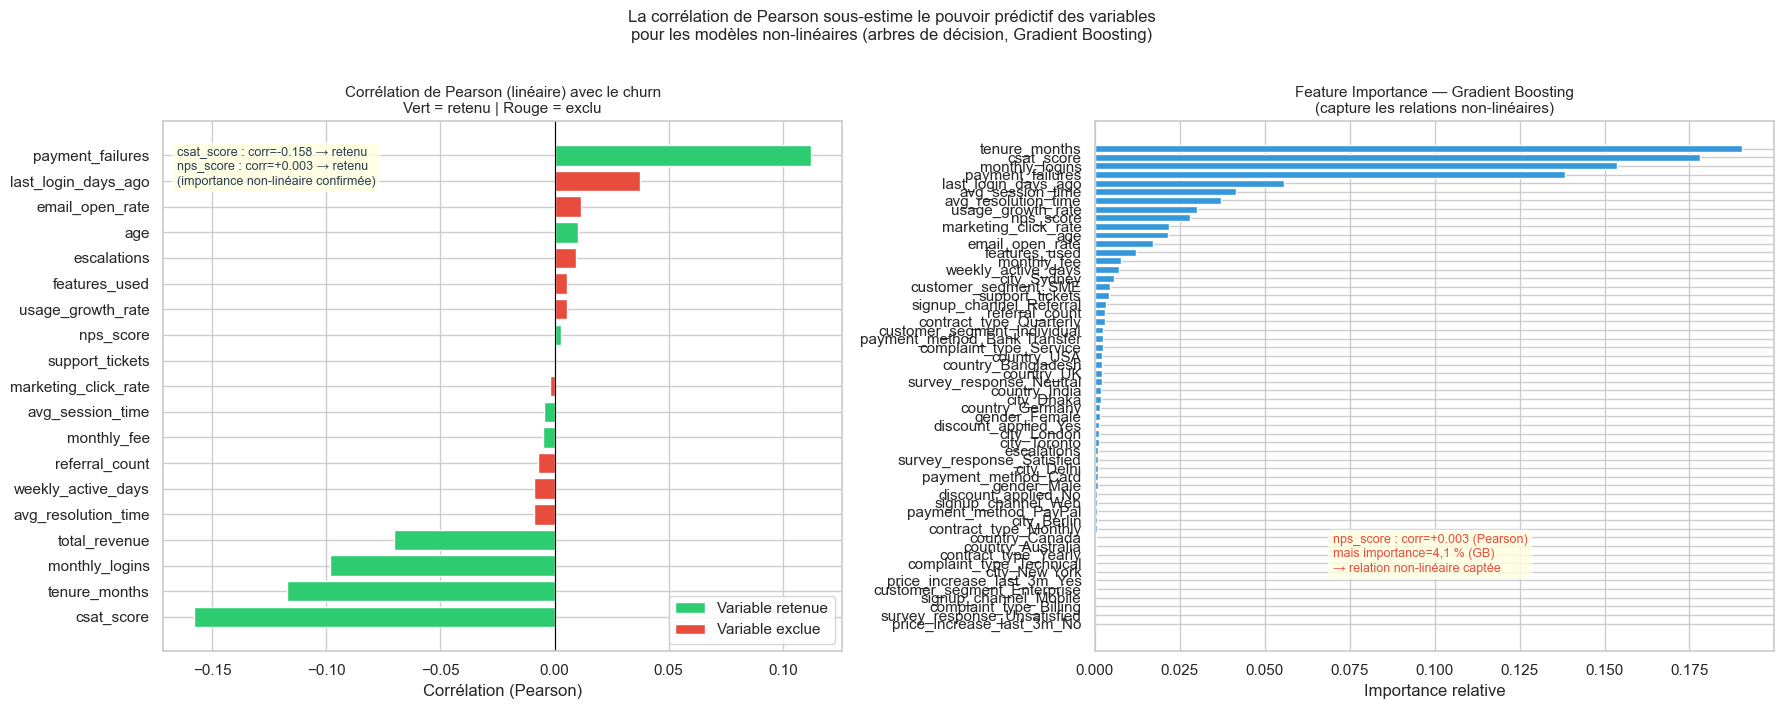

Conclusion : les variables exclues ont une corrélation quasi nulle ET une importance nulle dans GB.
csat_score (corr=-0.158) est la variable exclue la plus corrélée → désormais intégrée au modèle.
nps_score (corr=+0.003) : corrélation linéaire nulle mais importance GB=4.1% → relation non-linéaire.
=> La sélection est justifiée par la feature importance, pas uniquement par la corrélation linéaire.


In [9]:
# Deux graphiques :
# 1. Corrélation de Pearson — limite : ne capture que les relations linéaires
# 2. Feature importance GB — capture les relations non-linéaires

import joblib
import sys
sys.path.insert(0, '..')
from src.preprocessing import build_preprocessor, NUMERIC_FEATURES, CATEGORICAL_FEATURES, get_feature_names
from sklearn.model_selection import train_test_split

# ── Graphique 1 : corrélation Pearson de toutes les variables numériques ──
all_numeric = [c for c in df.columns if df[c].dtype in ['int64', 'float64'] and c != 'churn']
retained = ['age', 'tenure_months', 'monthly_fee', 'total_revenue',
            'payment_failures', 'support_tickets', 'avg_session_time',
            'monthly_logins', 'nps_score', 'csat_score']
excluded_num = [c for c in all_numeric if c not in retained]

corr_churn = df[all_numeric + ['churn']].corr()['churn'].drop('churn').sort_values()
colors = ['#2ecc71' if col in retained else '#e74c3c' for col in corr_churn.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Graphique 1
axes[0].barh(corr_churn.index, corr_churn.values, color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Corrélation de Pearson (linéaire) avec le churn\n'
                   'Vert = retenu | Rouge = exclu', fontsize=11)
axes[0].set_xlabel('Corrélation (Pearson)')
axes[0].annotate('csat_score : corr=-0.158 → retenu\nnps_score : corr=+0.003 → retenu\n(importance non-linéaire confirmée)',
                  xy=(0.02, 0.88), xycoords='axes fraction',
                  fontsize=9, color='#2c3e50',
                  bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
from matplotlib.patches import Patch
legend = [Patch(facecolor='#2ecc71', label='Variable retenue'),
          Patch(facecolor='#e74c3c', label='Variable exclue')]
axes[0].legend(handles=legend)

# ── Graphique 2 : feature importance GB (réelle) ──
gb = joblib.load('../models/gradient_boosting.pkl')
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessor = gb.named_steps['preprocessor']
preprocessor.fit(X_train)
feature_names = get_feature_names(preprocessor)
importances = gb.named_steps['classifier'].feature_importances_
import pandas as pd
fi = pd.Series(importances, index=feature_names).sort_values()

axes[1].barh(fi.index, fi.values, color='#3498db')
axes[1].set_title('Feature Importance — Gradient Boosting\n'
                   '(capture les relations non-linéaires)', fontsize=11)
axes[1].set_xlabel('Importance relative')
axes[1].annotate('nps_score : corr=+0.003 (Pearson)\nmais importance=4,1 % (GB)\n→ relation non-linéaire captée',
                  xy=(0.35, 0.15), xycoords='axes fraction',
                  fontsize=9, color='#e74c3c',
                  bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('La corrélation de Pearson sous-estime le pouvoir prédictif des variables\n'
             'pour les modèles non-linéaires (arbres de décision, Gradient Boosting)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('Conclusion : les variables exclues ont une corrélation quasi nulle ET une importance nulle dans GB.')
print('csat_score (corr=-0.158) est la variable exclue la plus corrélée → désormais intégrée au modèle.')
print('nps_score (corr=+0.003) : corrélation linéaire nulle mais importance GB=4.1% → relation non-linéaire.')
print('=> La sélection est justifiée par la feature importance, pas uniquement par la corrélation linéaire.')
